In [1]:
import gymnasium as gym
import numpy as np
import cv2
import ale_py
import torch

from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.atari_wrappers import FireResetEnv

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import glob
from datetime import datetime

In [3]:
gym.register_envs(ale_py)

In [4]:
log_dir = "./logs_breakout/"
os.makedirs(log_dir, exist_ok=True)

In [5]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(20, 40, 30, 30)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        if not self.apply_patch:
            return img
        
        # Copia para não alterar o buffer original inadvertidamente
        img = img.copy()
        
        # Detecta dimensões (pode ser 84x84 ou a resolução nativa no render)
        H, W = img.shape[:2]
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que o desenho não exceda as bordas
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            # Pinta de branco (255). Funciona tanto para RGB quanto Grayscale se ajustado
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # Mágica para o vídeo: Pega o render original e aplica a mancha nele
        img = self.env.render()
        return self._paint_patch(img)

In [6]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, apply_blur=False, region=(20, 40, 30, 30), ksize=21):
        super().__init__(env)
        self.apply_blur = apply_blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize if ksize % 2 == 1 else ksize + 1

    def _apply_blur(self, img):
        if not self.apply_blur:
            return img
        
        img = img.copy()
        H, W = img.shape[:2]
        x, y, w, h = self.x, self.y, self.w, self.h
        
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            roi = img[y:y_end, x:x_end]
            # Aplica Gaussian Blur na região de interesse
            blurred_roi = cv2.GaussianBlur(roi, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = blurred_roi
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info
    
    def render(self):
        img = self.env.render()
        return self._apply_blur(img)

In [7]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Força explicitamente o shape (H, W, 1) para compatibilidade com SB3
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def _convert(self, obs):
        # Se for RGB (3 canais), converte para Gray e mantém dimensão extra
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

In [8]:
def _create_base_gym_env(render_mode, with_modification, modification_type, log_dir=None):
    """
    Função interna para garantir que a ordem dos wrappers seja idêntica
    tanto no treino quanto no vídeo.
    """
    env = gym.make("ALE/Breakout-v5", render_mode=render_mode)
    
    # 1. Garante inicio do jogo
    env = FireResetEnv(env)
    
    # 2. Resize para 84x84 (Colorido)
    # façam sentido na imagem pequena.
    env = gym.wrappers.ResizeObservation(env, (84, 84))
    
    # 3. Aplica a Modificação Visual (Blur ou White Patch)
    if modification_type == 'white_patch':
        env = WhitePatchBreakout(env, apply_patch=with_modification, region=(20, 40, 30, 30))
    elif modification_type == 'blur':
        env = BlurBreakout(env, apply_blur=with_modification, region=(20, 40, 30, 30), ksize=21)
    

    if log_dir:
        env = Monitor(env, log_dir)
        
    return env

In [9]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino.
    Agora gera um arquivo monitor com TIMESTAMP para não sobrescrever os anteriores.
    Ex: ./logs/monitor_20231027_153000.csv
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)
    
    # Gera o timestamp UMA VEZ para este ambiente
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor (AGORA COM TIMESTAMP NO NOME)
        if log_dir:
            # Cria o caminho: ./logs/monitor_20231123_220000
            # O SB3 adiciona .csv automaticamente na maioria das versões
            filename = os.path.join(log_dir, f"monitor_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [10]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino mantendo a consistência exata com o ambiente de avaliação.
    Parâmetros renomeados para bater com sua chamada: with_blur, change.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor
        if log_dir:
            env = Monitor(env, log_dir)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [11]:
def make_training_env(with_blur=False, change='white_patch', zone='middle', log_dir="./logs/"):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # Coordenadas fixas para 84x84 (Mantendo mancha de 30x30)
    # X=27 centraliza horizontalmente (84 - 30) / 2
    presets = {
        # ZONA 1: TOP (TIJOLOS)
        # Y=18 estava alto. Vamos para Y=24.
        # X=25 corrige o deslocamento para a esquerda.
        'top':    (60, 55, 40, 40), 

        # ZONA 2: MIDDLE (TRAJETÓRIA/REAÇÃO)
        # Y=40 cobre a área onde a bola corre antes de chegar no paddle.
        # Fica logo abaixo da massa principal de tijolos.
        'middle': (60, 110, 40, 40), 

        # ZONA 3: BOTTOM (PADDLE)
        # Y=44 garante que a mancha vá até o pixel 84 (fim da tela).
        # Cobre totalmente a área de movimento do paddle.
        'bottom': (60, 165, 40, 40)  
    }
    
    # Seleciona a região baseada no nome, ou usa 'middle' como padrão
    region = presets.get(zone, (27, 40, 30, 30))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # Aplica a mancha na zona escolhida
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = GrayscaleWrapper(env)
        
        if log_dir:
            # Adiciona o nome da zona no log para diferenciar depois
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

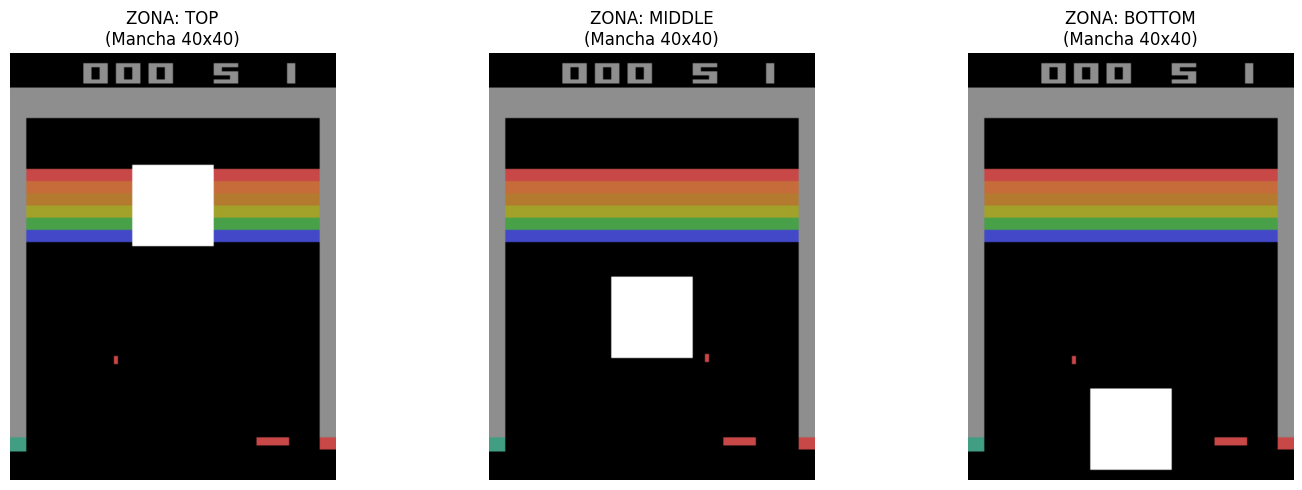

In [12]:
def debug_visualize_zones():
    zones = ['top', 'middle', 'bottom']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, zone in enumerate(zones):
        # Cria ambiente temporário
        env = make_training_env(with_blur=True, change='white_patch', zone=zone, log_dir=None)
        
        env.reset()
        # Dá alguns passos para o jogo começar e a bola aparecer (se possível)
        for _ in range(5):
            obs, _, _, _ = env.step([1]) # Fire/Noop
            
        # Pega o render colorido interno (O que nós vemos)
        # O env é um VecEnv, então acessamos envs[0]
        img = env.envs[0].render()
        
        axes[i].imshow(img)
        axes[i].set_title(f"ZONA: {zone.upper()}\n(Mancha 40x40)")
        axes[i].axis('off')
        
        env.close()
    
    plt.tight_layout()
    plt.show()

# RODE ISSO AGORA:
debug_visualize_zones()

In [13]:
def make_training_env(with_blur=False, change='white_patch', zone='middle', log_dir="./logs/"):
    """
    Cria ambiente com zonas configuráveis.
    Zonas disponíveis: 'top', 'middle', 'bottom'.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # --- CORREÇÃO DE ESCALA ---
    # A imagem da IA tem apenas 84x84 pixels.
    # Tamanho da Mancha: 40x40 pixels.
    # Centralização X: (84 - 40) / 2 = 22.
    
    presets = {
        # ZONA 1: TOP (TIJOLOS)
        # Y=25: Centraliza a mancha na massa de tijolos coloridos.
        'top':    (32, 25, 20, 20), 

        # ZONA 2: MIDDLE (TRAJETÓRIA)
        # Y=50: Fica no espaço vazio logo acima da linha de perigo.
        'middle': (32, 50, 20, 20), 

        # ZONA 3: BOTTOM (PADDLE)
        # Y=64: Vai exatamente até o pixel 84 (64+20=84).
        # Cobre apenas o centro do paddle, exigindo precisão.
        'bottom': (32, 64, 20, 20)  
    }
    
    region = presets.get(zone, (22, 38, 40, 40))

    def _init():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        
        # 1. Redimensiona PRIMEIRO (O mundo vira 84x84 aqui)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 2. Aplica a Mancha DEPOIS (Usando as coordenadas convertidas acima)
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
        env = GrayscaleWrapper(env)
        
        if log_dir:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = os.path.join(log_dir, f"monitor_{zone}_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

Gerando visualização para a zona: top...
Gerando visualização para a zona: middle...
Gerando visualização para a zona: bottom...


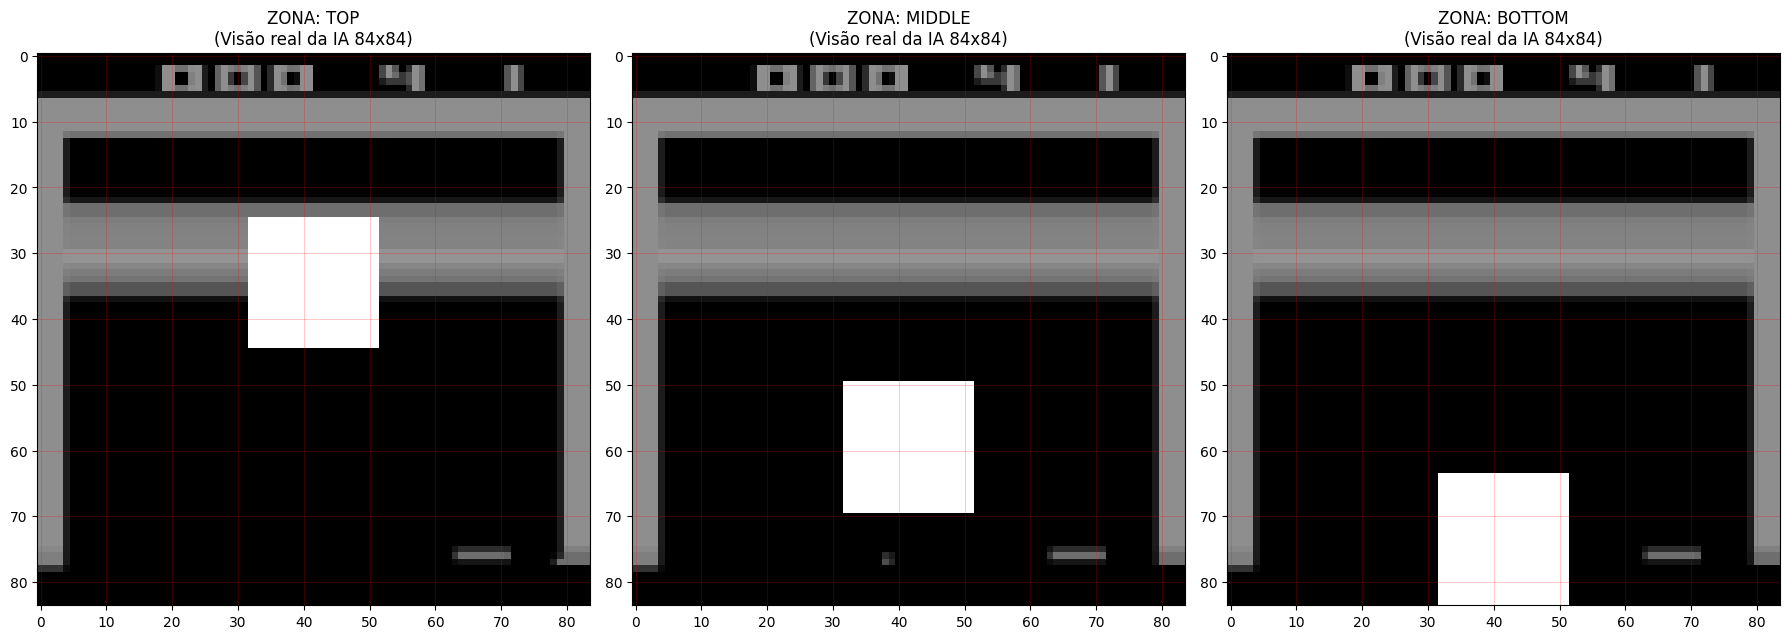

In [14]:
def visualize_agent_view():
    zones = ['top', 'middle', 'bottom']
    
    # Cria uma figura com 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, zone in enumerate(zones):
        print(f"Gerando visualização para a zona: {zone}...")
        
        # 1. Cria o ambiente com a zona específica
        # (Usa a função make_training_env que acabamos de corrigir)
        env = make_training_env(with_blur=True, change='white_patch', zone=zone, log_dir=None)
        
        obs = env.reset()
        
        # 2. Avança o jogo por 40 passos para garantir que:
        # - O jogo começou (FIRE)
        # - Os tijolos desceram (se for o caso)
        # - A bola apareceu
        for _ in range(40):
            # Envia ação 1 (FIRE) para iniciar, depois aleatório ou NOOP
            action = [1] 
            obs, _, _, _ = env.step(action)
            
        # 3. Extrai a imagem
        # O shape do obs é (1, 4, 84, 84) -> (Batch, Channels/Stack, Height, Width)
        # Pegamos o índice [0, 3, :, :] -> O último frame empilhado (o mais atual)
        frame_atual = obs[0, 3, :, :]
        
        # 4. Plota
        ax = axes[i]
        ax.imshow(frame_atual, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"ZONA: {zone.upper()}\n(Visão real da IA 84x84)", fontsize=12)
        
        # Adiciona linhas de grade para ajudar a contar pixels (opcional)
        ax.grid(color='red', linestyle='-', linewidth=0.5, alpha=0.3)
        ax.set_xticks(np.arange(0, 84, 10))
        ax.set_yticks(np.arange(0, 84, 10))
        
        env.close()

    plt.tight_layout()
    plt.show()

# Execute agora:
visualize_agent_view()

In [15]:
steps = 3_000_000

In [16]:
# DQN("CnnPolicy", 
#     env_blur, 
#     verbose=1,buffer_size=100_000,  
#     optimize_memory_usage=False,
#     learning_starts=50_000,
#     learning_rate=1e-4,
#     batch_size=32,
#     exploration_fraction=0.1,
#     exploration_final_eps=0.01,
#     train_freq=4,
#     target_update_interval=100,
#     gradient_steps=1,
#     tensorboard_log="./tensorboard_logs/")

In [17]:
# model_blur = DQN(
#     "CnnPolicy", 
#     env_blur, 
#     verbose=1, 
    
#     # 1. Memória (Buffer)
#     # Aumentar permite que o agente lembre de experiências mais antigas e variadas.
#     # Se der erro de memória RAM, diminua para 50_000 ou ative optimize_memory_usage=True
#     buffer_size=100_000,  
#     optimize_memory_usage=False, 

#     # 2. Quando começar a aprender
#     # Espere o buffer encher bastante antes de começar a atualizar os pesos.
#     # Isso evita overfitting em movimentos aleatórios iniciais.
#     learning_starts=50_000, 

#     # 3. Taxa de Aprendizado (Padrão Atari)
#     learning_rate=1e-4, 

#     # 4. Batch Size
#     # 32 é o clássico para Atari.
#     batch_size=32, 

#     # 5. Exploração (Epsilon-Greedy)
#     # exploration_fraction: Fração do total_timesteps que ele passa diminuindo a exploração.
#     # 0.1 (10%) de 1M steps = 100k steps explorando muito. 
#     exploration_fraction=0.1, 
#     # exploration_final_eps: No final, 1% de chance de movimento aleatório é melhor que 5% no Breakout.
#     exploration_final_eps=0.01, 

#     # 6. Frequência de Treino
#     # Treina a cada 4 passos do ambiente (Padrão do artigo Nature).
#     train_freq=4, 
    
#     # 7. Atualização da Rede Alvo (Estabilidade)
#     # A cada 1000 passos, copia os pesos para a rede alvo.
#     target_update_interval=1000, 
    
#     # 8. Gradiente
#     gradient_steps=1,
    
#     # (Opcional) Logs para Tensorboard (visualizar gráficos em tempo real)
#     tensorboard_log="./tensorboard_logs/"
# )

In [18]:
import tqdm, rich

In [19]:
steps_total = 3_000_000  # Recomendado: 3 Milhões
# steps_total = 100_000  # Use este valor baixo SÓ se for testar se o código roda sem erro

# Lista de experimentos para rodar
# Formato: (Nome do Arquivo, Com Blur?, Qual Zona?)
experimentos = [
    ("dqn_breakout_normal",      False, "middle"), # Normal (Zona tanto faz pq with_blur=False)
    ("dqn_breakout_zone_top",    True,  "top"),    # Hipótese Planejamento
    ("dqn_breakout_zone_middle", True,  "middle"), # Hipótese Trajetória
    ("dqn_breakout_zone_bottom", True,  "bottom")  # Hipótese Propriocepção
]

print(f"--- INICIANDO BATERIA DE 4 TREINAMENTOS ---")
print(f"Total de Steps por agente: {steps_total}")

for nome_modelo, usar_blur, zona in experimentos:
    
    start_time = time.time()
    
    # 1. Título bonito para o log
    tipo = "NORMAL (SEM MANCHA)" if not usar_blur else f"COM MANCHA - ZONA {zona.upper()}"
    print(f"\n{'='*60}")
    print(f" TREINANDO: {tipo}")
    print(f" Arquivo de saída: {nome_modelo}")
    print(f"{'='*60}")
    
    # 2. Define pasta de log única para cada um
    # Se for normal, pasta logs_normal, senão logs_hipotese_zona
    if not usar_blur:
        current_log_dir = "./logs_normal/"
    else:
        current_log_dir = f"./logs_hipotese_{zona}/"
    
    # 3. Cria o Ambiente
    # Nota: Se usar_blur=False, o parametro 'zone' é ignorado pela lógica interna, o que está correto.
    env = make_training_env(with_blur=usar_blur, change='white_patch', zone=zona, log_dir=current_log_dir)
    
    # 4. Define o Modelo (Hiperparâmetros idênticos para todos)
    model = DQN(
        "CnnPolicy", 
        env,    
        #learning_rate is the learning rate of the model
        learning_rate =5e-5,  #first trial: 5e-4   #second trial: 1e-4  #third trial: 1e-3  #fourth trial: 5e-5 #fifth trial: 5e-5 gamma = 0.90 #sixth trial: 1e-4 gamma = 0.90 #seventh trial: 5e-4 gamma = 0.90
        # buffer_size is the size of the replay buffer
        buffer_size=100000,
        #learning_starts is the number of timesteps before the first interaction with the environment
        learning_starts=50000,
        #batch_size is the number of samples that will be taken from the replay buffer for training the model
        batch_size=64,
        #tau is the soft update coefficient for updating the target network if set to 1 then the target network is hard updated every target_update_interval timesteps
        tau= 1.0,
        #gamma is the discount factor 
        gamma=0.90,
        #train_freq is the number of timesteps between each training step
        train_freq=4,
        #gradient_steps is the number of gradient steps to take after each rollout
        gradient_steps=1,
        #replay_buffer_class is the class of the replay buffer
        replay_buffer_class=None,
        #replay_buffer_kwargs is the keyword arguments for the replay buffer
        replay_buffer_kwargs=None,
        #optimize_memory_usage is a boolean that indicates if the memory usage will be optimized
        optimize_memory_usage=False,
        #target_update_interval is the number of timesteps between each target network update
        target_update_interval=10000,
        #exploration_fraction is the fraction of the total number of timesteps that the exploration rate will be annealed
        exploration_fraction=0.1,
        #exploration_initial_eps is the initial value of the exploration rate
        exploration_initial_eps=1.0,
        #exploration_final_eps is the final value of the exploration rate
        exploration_final_eps=0.05,
        #max_grad_norm is the maximum value of the gradient norm
        max_grad_norm=0.5,
        #stats_window_size is the size of the window for computing the stats
        stats_window_size=100,
        #policy_kwargs is the keyword arguments for the policy
        policy_kwargs=None,
        #verbose is the verbosity level: 0 no output, 1 info, 2 debug
        verbose=2,
        #seed is the seed for the pseudo random number generator
        seed=None,
        #device is the device on which the model will be trained
        device= "cuda" if torch.cuda.is_available() else "cpu"
        )
    
    # 5. Treina
    try:
        model.learn(total_timesteps=steps_total, progress_bar=True)
        
        # 6. Salva
        model.save(nome_modelo)
        print(f"--> Modelo salvo: {nome_modelo}.zip")
        
    except Exception as e:
        print(f"!!! ERRO AO TREINAR {nome_modelo}: {e}")
        
    finally:
        # Garante que o ambiente fecha para liberar memória
        env.close()
        elapsed = (time.time() - start_time) / 3600
        print(f"--> Tempo decorrido neste agente: {elapsed:.2f} horas")

print("\n\n################################################")
print(" TODAS AS SESSÕES DE TREINAMENTO FORAM CONCLUÍDAS")
print("################################################")

--- INICIANDO BATERIA DE 4 TREINAMENTOS ---
Total de Steps por agente: 3000000

 TREINANDO: NORMAL (SEM MANCHA)
 Arquivo de saída: dqn_breakout_normal
Using cpu device


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\stable_baselines3\common\buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 5.65GB > 4.63GB
  warnings.warn(


c:\Users\user\Documents\mestrado\BlurRL\.venv\lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 198      |
|    ep_rew_mean      | 1.75     |
|    exploration_rate | 0.997    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1488     |
|    time_elapsed     | 0        |
|    total_timesteps  | 794      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 185      |
|    ep_rew_mean      | 1.38     |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1484     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1480     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 182      |
|    ep_rew_mean      | 1.25     |
|    exploration_rate | 0.993    |
| time/               |          |
|    episodes       

--> Tempo decorrido neste agente: 7.45 horas

KeyboardInterrupt: 

In [ ]:
# print("--- Iniciando Treino SEM Blur ---")
# env_normal = make_training_env(with_blur=False, change = 'white_patch', log_dir=log_dir_clean)
# # model_normal = DQN("CnnPolicy", env_normal, verbose=1, buffer_size=50_000, learning_starts=10_000, train_freq=4) 
# model_normal = DQN("CnnPolicy", 
#     env_normal, 
#     verbose=1,buffer_size=100_000,  
#     optimize_memory_usage=False,
#     learning_starts=50_000,
#     learning_rate=1e-4,
#     batch_size=32,
#     exploration_fraction=0.1,
#     exploration_final_eps=0.01,
#     train_freq=4,
#     target_update_interval=1000,
#     gradient_steps=1)

# model_normal.learn(total_timesteps=steps) # Baixo para teste rápido
# model_normal.save("dqn_breakout_normal")
# env_normal.close()

In [ ]:
# # Configuração
# steps_por_zona = steps  # Ajuste conforme seu tempo disponível
# zonas = ['top', 'middle', 'bottom']

# for zona in zonas:
#     print(f"\n=============================================")
#     print(f" INICIANDO TREINO: ZONA {zona.upper()}")
#     print(f"=============================================")
    
#     # Define diretório de log específico para não misturar
#     log_dir = f"./logs_hipotese_{zona}/"
    
#     # Cria ambiente na zona específica
#     env = make_training_env(with_blur=True, change='white_patch', zone=zona, log_dir=log_dir)
    
#     # Cria Modelo DQN (Configuração Otimizada que definimos antes)
#     model = DQN(
#         "CnnPolicy", 
#         env, 
#         verbose=1,buffer_size=100_000,
#         optimize_memory_usage=False,
#         learning_starts=50_000,
#         learning_rate=1e-4,
#         batch_size=32,
#         exploration_fraction=0.1,
#         exploration_final_eps=0.01,
#         train_freq=4,
#         target_update_interval=1000,
#         gradient_steps=1
#         )
    
#     # Treina
#     model.learn(total_timesteps=steps_por_zona)
    
#     # Salva com nome distinto
#     model.save(f"dqn_breakout_zone_{zona}")
    
#     env.close()
#     print(f"Modelo da zona {zona} salvo com sucesso!")

# print("\n--- Todos os experimentos finalizados ---")

In [ ]:
# def record_video(model, name_prefix, with_blur, change='white_patch', zone='middle', n_episodes=1, max_steps=3000):
#     video_folder = "./videos/"
#     os.makedirs(video_folder, exist_ok=True)
    
#     print(f"--- Gravando {name_prefix} [Zona: {zone}] (Max {max_steps} steps) ---")

#     # Coordenadas das zonas (Devem ser IDÊNTICAS ao treino)
#     presets = {
#         # ZONA 1: TIJOLOS (Y=22)
#         # Cobre a maioria das linhas coloridas.
#         'top':    (27, 22, 30, 30), 

#         # ZONA 2: TRAJETÓRIA/VAZIO (Y=48)
#         # Fica entre os tijolos e o paddle. Onde a bola corre livre.
#         'middle': (27, 48, 30, 30), 

#         # ZONA 3: PADDLE/AGENTE (Y=54)
#         # Vai do pixel 54 até 84 (fim da tela). Cobre o agente totalmente.
#         'bottom': (27, 54, 30, 30)  
#     }
#     region = presets.get(zone, (27, 40, 30, 30))

#     def _create_video_env():
#         env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
#         env = FireResetEnv(env)
#         env = gym.wrappers.ResizeObservation(env, (84, 84))
        
#         # Aplica a mancha na zona correta
#         if change == 'white_patch':
#             env = WhitePatchBreakout(env, apply_patch=with_blur, region=region)
#         elif change == 'blur':
#             env = BlurBreakout(env, apply_blur=with_blur, region=region, ksize=21)
        
#         env = gym.wrappers.RecordVideo(
#             env, 
#             video_folder=video_folder, 
#             name_prefix=name_prefix,
#             episode_trigger=lambda x: True,
#             disable_logger=True
#         )
        
#         env = GrayscaleWrapper(env)
#         return env

#     env = DummyVecEnv([_create_video_env])
#     env = VecTransposeImage(env)
#     env = VecFrameStack(env, n_stack=4)

#     obs = env.reset()
#     episodes_count = 0
#     current_steps = 0
#     last_lives = 5 
    
#     try:
#         while episodes_count < n_episodes:
#             action, _ = model.predict(obs, deterministic=True)
            
#             # --- Anti-Stuck: Força FIRE se ficar parado demais ---
#             # (Mantenha sua lógica de vidas ou use um contador de ações repetidas)
            
#             obs, rewards, done, infos = env.step(action)
#             current_steps += 1
            
#             # Checagem de vidas para atualizar last_lives
#             for info in infos:
#                 lives = info.get("lives", 0)
#                 if lives < last_lives:
#                     last_lives = lives
            
#             if current_steps > max_steps:
#                 print(f"ALERTA: Episódio excedeu {max_steps} passos. Forçando parada.")
#                 done = [True]
            
#             for i, d in enumerate(done):
#                 if d:
#                     episodes_count += 1
#                     current_steps = 0
#                     last_lives = 5
#                     score = infos[i].get('episode', {}).get('r', 0)
#                     print(f"Episódio {episodes_count} finalizado | Score: {score}")
#                     obs = env.reset()
                    
#     except KeyboardInterrupt:
#         print("Interrompido.")
#     finally:
#         env.close()
#         print(f"Vídeos salvos em {video_folder}")

In [ ]:
# if os.path.exists("dqn_breakout_zone_top.zip"):
#     print(">>> Carregando Modelo TOP...")
#     model_top = DQN.load("dqn_breakout_zone_top")
    
#     record_video(
#         model=model_top, 
#         name_prefix="video_teste_TOP", 
#         with_blur=True, 
#         change='white_patch', 
#         zone='top',  # <--- IMPORTANTE: Mudar para 'top'
#         n_episodes=2
#     )

In [ ]:
# if os.path.exists("dqn_breakout_zone_middle.zip"): # Ou o nome que você usou antes
#     print("\n>>> Carregando Modelo MIDDLE...")
#     model_middle = DQN.load("dqn_breakout_zone_middle")
    
#     record_video(
#         model=model_middle, 
#         name_prefix="video_teste_MIDDLE", 
#         with_blur=True, 
#         change='white_patch', 
#         zone='middle', 
#         n_episodes=2
#     )

In [ ]:
# record_video(model_blur, "teste_com_blur", with_blur=True, change = 'white_patch', n_episodes=5)

In [ ]:
# record_video(model_normal, "teste_sem_blur", with_blur=False, change = 'white_patch', n_episodes=5, max_steps=100_000)